# Test: CaSR File Download

In this notebook, we will download data from https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/download_CaSR_regions_var_period.html and visualize them.



## Download Paths





### Variables: Forcing

| Variable            | Long Name                                       | Type     | Unit  | Level   | Freq.  | Grid Range                                    | Year |
|---------------------|-------------------------------------------------|----------|-------|---------|--------|-----------------------------------------------|------|
| CaSR_v3.2_P_PR0_SFC | Quantity of precipitation (1h)                  | forecast | m     | surface | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_TT_1.5m | Air temperature                                 | forecast | °C    | 1.5m    | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_HU_1.5m | Specific humidity                               | forecast | kg/kg | 1.5m    | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_FB_SFC  | Downward solar flux                             | forecast | W/m²  | surface | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_FI_SFC  | Surface incoming infrared flux                  | forecast | W/m²  | surface | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_PN_SFC  | Sea level pressure                              | forecast | mb    | surface | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_UUC_10m | Corrected U-component of the wind (West-East)   | forecast | kts   | 10m     | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |
| CaSR_v3.2_P_VVC_10m | Corrected V-component of the wind (South-North) | forecast | kts   | 10m     | 1 hour | rlon: 141-175, 176-210 rlat: 421-455, 456-490 | 2024 |

### DownLoad Command

**wget -c -i CaSRv3p2_file-list.txt -P target-directory -B base-URL**

where

**-c**: resume getting a partially-downloaded file

**CaSRv3p2_file-list.txt**: text file containing a list of desired files as can be obtained 

**base-URL**: https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/data/CaSRv3.2/netcdf_tile/

**target-directory**: directory where downloaded file will be saved locally

## Download and Integration

### Download Command

Note that we need to download the big files into /ocean. 

In [1]:
# Download files using given URL and commands
import os
import subprocess

# FilePaths
file_list = "/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/CaSRv3p2_file-list_2024.txt"
target_dir = "/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Data_2024"
base_url = "https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/data/CaSRv3.2/netcdf_tile/"

# Target directory
os.makedirs(target_dir, exist_ok=True)
print(f"Target directory confirmed: {target_dir}")

# txt fnames
if not os.path.exists(file_list):
    print(f"No file list found: {file_list}")
else:
    print("Starting batch download, please wait...")
    
    # wget command
    command = [
        "wget", 
        "-c",  
        "-i", file_list, 
        "-P", target_dir, 
        "-B", base_url
    ]
    
    # run
    try:
        # Print progress
        result = subprocess.run(command, check=True)
        print("All files downloaded successfully!")
    except subprocess.CalledProcessError as e:
        print(f"An error occurred during download. Error code: {e.returncode}")

Target directory confirmed: /home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Data_2024
Starting batch download, please wait...


--2026-03-12 13:20:48--  https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/data/CaSRv3.2/netcdf_tile/rlon141-175_rlat421-455/CaSR_v3.2_P_FB_SFC_rlon141-175_rlat421-455_2024-2024.nc
Resolving hpfx.collab.science.gc.ca (hpfx.collab.science.gc.ca)... 142.98.224.27
Connecting to hpfx.collab.science.gc.ca (hpfx.collab.science.gc.ca)|142.98.224.27|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

--2026-03-12 13:20:48--  https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/data/CaSRv3.2/netcdf_tile/rlon141-175_rlat456-490/CaSR_v3.2_P_FB_SFC_rlon141-175_rlat456-490_2024-2024.nc
Reusing existing connection to hpfx.collab.science.gc.ca:443.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

--2026-03-12 13:20:48--  https://hpfx.collab.science.gc.ca/~scar700/rcas-casr/data/CaSRv3.2/netcdf_tile/rlon176-210_rlat

All files downloaded successfully!


416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



### Data Integration

In [2]:
# Data Merge
import xarray as xr
import glob
import os

# Define the base directory where all .nc files are stored directly
base_dir = '/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Data_2024/'

# List of the 8 variables extracted from your data
# variables = [
#    'P_FB_SFC', 'P_FI_SFC', 'P_HU_1.5m', 'P_PN_SFC', 
#    'P_PR0_SFC', 'P_TT_1.5m', 'P_UUC_10m', 'P_VVC_10m'
#]

variables = ['P_VVC_10m']

for var in variables:
    print(f"Processing variable: {var} ...")
    
    # Updated search pattern: looking directly inside Data_2024 (no subdirectories)
    search_pattern = os.path.join(base_dir, f'CaSR_v3.2_{var}_*.nc')
    tile_files = sorted(glob.glob(search_pattern))
    
    if not tile_files:
        print(f"  Warning: No files found for {var}. Please check the directory.")
        continue
        
    print(f"  -> Found {len(tile_files)} tile files to combine.")
    
    # Open and combine the datasets by coordinates (spatial merging)
    combined = xr.open_mfdataset(tile_files, combine='by_coords', parallel=True)
    
    # Fix the 'rotated_pole' variable as it doesn't depend on rlat/rlon
    # This keeps the original author's logic intact
    ds = xr.open_dataset(tile_files[0])
    combined['rotated_pole'] = ds['rotated_pole']
    
    # Define the output filename for the merged data
    output_file = os.path.join(base_dir, f"CaSR_v3.2_{var}_merged_2024.nc")
    
    # Save the combined dataset to a new NetCDF file with UNLIMITED time dimension
    combined.to_netcdf(output_file, unlimited_dims='time')
    
    print(f"  Success! Saved merged file: CaSR_v3.2_{var}_merged_2024.nc\n")
    
    # Close datasets to free up memory before the next loop iteration
    combined.close()
    ds.close()

print("All 8 variables have been successfully spatially merged!")

Processing variable: P_VVC_10m ...
  -> Found 4 tile files to combine.


/tmp/ipykernel_164487/101191557.py:31: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined = xr.open_mfdataset(tile_files, combine='by_coords', parallel=True)
/tmp/ipykernel_164487/101191557.py:31: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined = xr.open_mfdataset(tile_files, combine='by_coords', par

KeyboardInterrupt: 

## Range Display


/home/jqiu/conda_envs/analysis-junqi/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/jqiu/conda_envs/analysis-junqi/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/jqiu/conda_envs/analysis-junqi/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/jqiu/conda_envs/analysis-junqi/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', 

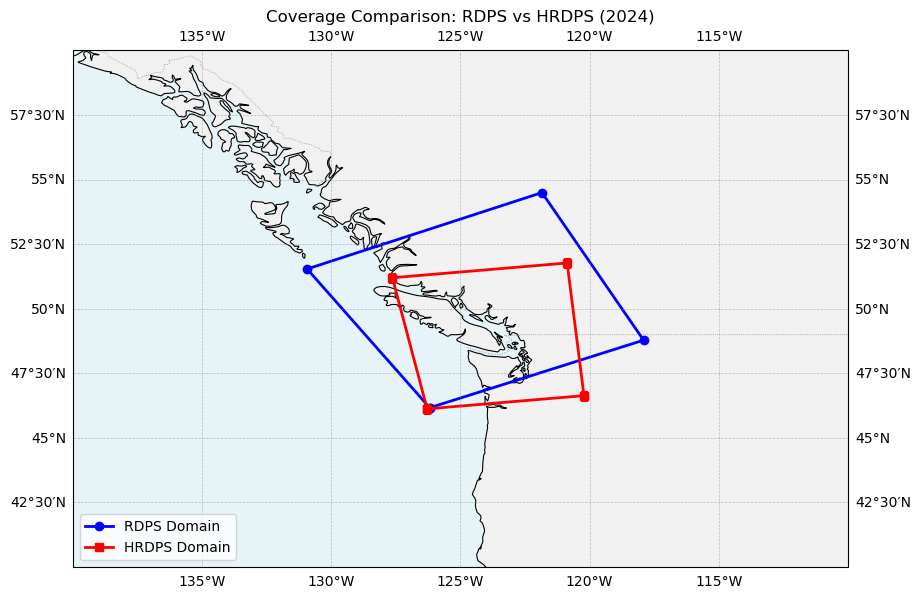

In [ ]:
# Range Comparison
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def get_valid_four_corners(file_path):
    """
    读取 nc 文件，过滤掉 (0,0) 的异常点，返回有效数据区域的四个顶点经纬度。
    """
    try:
        # 使用 xarray 读取数据
        ds = xr.open_dataset(file_path)
    except Exception as e:
        print(f"读取文件失败: {file_path}\n错误信息: {e}")
        return None, None

    # 尝试自动匹配经纬度变量名
    lat_vars = ['lat', 'latitude', 'nav_lat']
    lon_vars = ['lon', 'longitude', 'nav_lon']
    
    lat_name = next((var for var in lat_vars if var in ds.variables), None)
    lon_name = next((var for var in lon_vars if var in ds.variables), None)
    
    if not lat_name or not lon_name:
        print(f"在 {file_path} 中找不到常规的经纬度变量名。")
        return None, None

    lat = ds[lat_name].values
    lon = ds[lon_name].values

    # 如果经纬度是 1D 的，将其转换为 2D 网格
    if lat.ndim == 1 and lon.ndim == 1:
        lon, lat = np.meshgrid(lon, lat)

    # 统一将经度转换到 -180 到 180 的范围（以防有些数据是 0 到 360）
    lon = np.where(lon > 180, lon - 360, lon)

    # 核心步骤：过滤掉 lat=0 且 lon=0 的无效点，以及 NaN 值
    valid_mask = ~((np.isclose(lat, 0)) & (np.isclose(lon, 0))) & ~np.isnan(lat) & ~np.isnan(lon)
    
    # 找到有效数据在矩阵中的行列索引范围
    valid_y, valid_x = np.where(valid_mask)
    if len(valid_y) == 0:
        print(f"文件 {file_path} 中没有找到有效的经纬度数据。")
        return None, None

    y_min, y_max = valid_y.min(), valid_y.max()
    x_min, x_max = valid_x.min(), valid_x.max()

    # 提取四个顶点：左下、右下、右上、左上
    corners_lon = [
        lon[y_min, x_min], lon[y_min, x_max], 
        lon[y_max, x_max], lon[y_max, x_min]
    ]
    corners_lat = [
        lat[y_min, x_min], lat[y_min, x_max], 
        lat[y_max, x_max], lat[y_max, x_min]
    ]
    
    # 闭合多边形（将第一个点加到最后）
    corners_lon.append(corners_lon[0])
    corners_lat.append(corners_lat[0])

    ds.close()
    return corners_lon, corners_lat

def plot_domains():
    # 定义文件路径
    file_rdps = '/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Data_2024/Merged_2024/CaSR_v3.2_P_FB_SFC_merged_2024.nc'
    file_hrdps = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2024m01d01.nc'

    # 获取边界坐标
    rdps_lon, rdps_lat = get_valid_four_corners(file_rdps)
    hrdps_lon, hrdps_lat = get_valid_four_corners(file_hrdps)

    # 初始化地图
    fig = plt.figure(figsize=(10, 8))
    # 中心经纬度大致设置在北美
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    # 添加地图特征（岸线、陆地、国界）
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':', edgecolor='gray')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)

    # 绘制 RDPS 范围（蓝色）
    if rdps_lon and rdps_lat:
        ax.plot(rdps_lon, rdps_lat, transform=ccrs.PlateCarree(), 
                color='blue', linewidth=2, label='RDPS Domain', marker='o')
        
    # 绘制 HRDPS 范围（红色）
    if hrdps_lon and hrdps_lat:
        ax.plot(hrdps_lon, hrdps_lat, transform=ccrs.PlateCarree(), 
                color='red', linewidth=2, label='HRDPS Domain', marker='s')

    # 设置地图显示范围（根据两个数据的最大最小经纬度自动缩放，或者手动写死）
    ax.set_global() 
    ax.set_extent([-140, -110, 40, 60], crs=ccrs.PlateCarree()) # 这里设定了大概的北美范围，可按需微调

    # 添加网格线和图例
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    plt.legend(loc='lower left')
    plt.title('Coverage Comparison: RDPS vs HRDPS (2024)')
    
    # 渲染显示，或者你也可以用 plt.savefig('domain_plot.png', dpi=300) 来保存图片
    plt.show()

if __name__ == '__main__':
    plot_domains()

## Variable Inspection

In [4]:
# NC Info
import xarray as xr

def print_nc_info(file_path):
    try:
        ds = xr.open_dataset(file_path)
    except Exception as e:
        print(f"读取文件失败: {e}")
        return

    print(f"=== {file_path.split('/')[-1]} 变量信息 ===\n")
    # 打印表头
    print(f"{'变量名 (Variable)':<15} | {'维度 (Dims)':<25} | {'类型 (dtype)':<10} | {'单位 (Units)':<15} | {'长名称 (Long Name)'}")
    print("-" * 90)

    # 遍历并打印每个变量的信息
    for var_name, var_data in ds.variables.items():
        dims = str(var_data.dims)
        dtype = str(var_data.dtype)
        attrs = var_data.attrs
        
        long_name = attrs.get('long_name', attrs.get('standard_name', ''))
        units = attrs.get('units', '')
        
        print(f"{var_name:<17} | {dims:<25} | {dtype:<12} | {units:<17} | {long_name}")

    ds.close()

if __name__ == '__main__':
    hrdps_file = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2024m01d01.nc'
    print_nc_info(hrdps_file)

=== hrdps_y2024m01d01.nc 变量信息 ===

变量名 (Variable)  | 维度 (Dims)                 | 类型 (dtype) | 单位 (Units)      | 长名称 (Long Name)
------------------------------------------------------------------------------------------
LHTFL_surface     | ('time_counter', 'y', 'x') | float32      | W m-2             | Latent heat net flux
PRATE_surface     | ('time_counter', 'y', 'x') | float32      | kg m-2 s-1        | Precipitation rate
RH_2maboveground  | ('time_counter', 'y', 'x') | float32      | %                 | 2 metre relative humidity
atmpres           | ('time_counter', 'y', 'x') | float32      | Pa                | Air Pressure at MSL
precip            | ('time_counter', 'y', 'x') | float32      | kg m-2 s-1        | Precipitation Flux
qair              | ('time_counter', 'y', 'x') | float32      | kg kg-1           | Specific Humidity at 2m
solar             | ('time_counter', 'y', 'x') | float32      | W m-2             | Downward Short-Wave (Solar) Radiation Flux
tair              | (

| Physical Quantity    | HRDPS Variable         | HRDPS Unit | RDPS Variable       | RDPS Unit | Notes / Differences                                                 |
|----------------------|------------------------|------------|---------------------|-----------|---------------------------------------------------------------------|
| Air Temperature      | tair                   | K          | CaSR_v3.2_P_TT_1.5m | °C        | Different units; slight height difference (2m vs 1.5m).             |
| Specific Humidity    | qair                   | kg kg-1    | CaSR_v3.2_P_HU_1.5m | kg/kg     | Same units; slight height difference (2m vs 1.5m).                  |
| Precipitation        | precip / PRATE_surface | kg m-2 s-1 | CaSR_v3.2_P_PR0_SFC | m         | RDPS is accumulated (m), HRDPS is a rate/flux; requires conversion. |
| Short-Wave Radiation | solar                  | W m-2      | CaSR_v3.2_P_FB_SFC  | W/m²      | Downward solar flux; same units.                                    |
| Long-Wave Radiation  | therm_rad              | W m-2      | CaSR_v3.2_P_FI_SFC  | W/m²      | Surface incoming infrared flux; same units.                         |
| Sea Level Pressure   | atmpres                | Pa         | CaSR_v3.2_P_PN_SFC  | mb        | Different units (1 mb = 1 hPa = 100 Pa).                            |
| U-Wind (West-East)   | u_wind                 | m s-1      | CaSR_v3.2_P_UUC_10m | kts       | Different units (1 knot ≈ 0.5144 m/s).                              |
| V-Wind (South-North) | v_wind                 | m s-1      | CaSR_v3.2_P_VVC_10m | kts       | Different units (1 knot ≈ 0.5144 m/s).                              |

Variables Unique to **HRDPS**:

**LHTFL_surface**: Latent heat net flux (W m-2)

**RH_2maboveground**: 2-metre relative humidity (%) - Note: RDPS provides specific humidity but not direct relative humidity.

## Error Comparison


In [2]:
# U-Wind Comparison
import xarray as xr
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import random

def compare_u_wind_aligned():
    # 1. 固定随机种子，保证每次跑抽出来的点都一样
    random_seed = 42
    random.seed(random_seed)
    np.random.seed(random_seed)

    # 2. 定义文件路径
    rdps_file = '/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Data_2024/Merged_2024/CaSR_v3.2_P_UUC_10m_merged_2024.nc'
    hrdps_file = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2024m01d01.nc'

    print("正在加载数据集...")
    try:
        ds_rdps = xr.open_dataset(rdps_file)
        ds_hrdps = xr.open_dataset(hrdps_file)
    except Exception as e:
        print(f"读取文件失败: {e}")
        return

    # 3. 时间对齐 (锁定 2024-01-01 12:00:00)
    target_time = '2024-01-01T12:00:00'
    print(f"正在对齐时间至: {target_time} ...")
    
    try:
        # RDPS 通常时间维度叫 time，HRDPS 叫 time_counter
        # 使用 method='nearest' 防止时间戳有几秒钟的微小误差导致报错
        rdps_step = ds_rdps.sel(time=target_time, method='nearest')
        hrdps_step = ds_hrdps.sel(time_counter=target_time, method='nearest')
    except Exception as e:
        print(f"时间对齐失败，请检查文件中的时间维度命名或时间范围: {e}")
        return

    # 4. 提取数据和经纬度
    # HRDPS 数据提取
    u_hrdps = hrdps_step['u_wind'].values
    lat_hrdps = ds_hrdps['nav_lat'].values
    lon_hrdps = ds_hrdps['nav_lon'].values
    # 确保 HRDPS 经度是 -180 到 180
    lon_hrdps = np.where(lon_hrdps > 180, lon_hrdps - 360, lon_hrdps)

    # RDPS 数据提取
    u_rdps_kts = rdps_step['CaSR_v3.2_P_UUC_10m'].values
    # 动态获取 RDPS 经纬度变量名
    lat_rdps_name = next((v for v in ['lat', 'latitude', 'nav_lat'] if v in ds_rdps.variables), None)
    lon_rdps_name = next((v for v in ['lon', 'longitude', 'nav_lon'] if v in ds_rdps.variables), None)
    lat_rdps = ds_rdps[lat_rdps_name].values
    lon_rdps = ds_rdps[lon_rdps_name].values
    # 确保 RDPS 经度也是 -180 到 180
    lon_rdps = np.where(lon_rdps > 180, lon_rdps - 360, lon_rdps)

    # 5. 构建 HRDPS 的 KDTree (因为我们这次要从 RDPS 找 HRDPS)
    print("正在构建 HRDPS 空间索引...")
    valid_hrdps_mask = ~np.isnan(lat_hrdps) & ~np.isnan(lon_hrdps) & ~np.isnan(u_hrdps) & ~((np.isclose(lat_hrdps, 0)) & (np.isclose(lon_hrdps, 0)))
    
    hrdps_coords = np.column_stack((lat_hrdps[valid_hrdps_mask], lon_hrdps[valid_hrdps_mask]))
    hrdps_u_values = u_hrdps[valid_hrdps_mask]
    
    tree = cKDTree(hrdps_coords)

    # 6. 在 RDPS 中随机抽样
    print("正在从 RDPS 抽样并寻找 HRDPS 对应点...")
    valid_rdps_mask = ~np.isnan(lat_rdps) & ~np.isnan(lon_rdps) & ~np.isnan(u_rdps_kts)
    valid_rdps_indices = np.where(valid_rdps_mask)
    
    num_samples = 15
    # 如果可用点少于要抽样的数量，就取全部可用点
    actual_samples = min(num_samples, len(valid_rdps_indices[0]))
    sample_idx = random.sample(range(len(valid_rdps_indices[0])), actual_samples)
    
    results = []
    
    for idx in sample_idx:
        # RDPS 如果是 1D 经纬度网格（很多时候低分辨率网格是 1D 的）
        if lat_rdps.ndim == 1:
            y_idx, x_idx = valid_rdps_indices[0][idx], valid_rdps_indices[1][idx]
            target_lat = lat_rdps[y_idx]
            target_lon = lon_rdps[x_idx]
        else: # 2D 网格
            y_idx, x_idx = valid_rdps_indices[0][idx], valid_rdps_indices[1][idx]
            target_lat = lat_rdps[y_idx, x_idx]
            target_lon = lon_rdps[y_idx, x_idx]
            
        rdps_u_val_kts = u_rdps_kts[y_idx, x_idx]
        
        # 核心：将 RDPS 转换为 m/s
        rdps_u_val_ms = rdps_u_val_kts * 0.514444
        
        # 在 HRDPS 中找最近点
        dist, hrdps_idx = tree.query([target_lat, target_lon], k=1)
        
        # 距离阈值：大概 0.2 度（视具体纬度而定，约 20km）。超出的说明 RDPS 点在 HRDPS 范围外
        if dist > 0.2:
            continue
            
        hrdps_u_val = hrdps_u_values[hrdps_idx]
        diff = hrdps_u_val - rdps_u_val_ms
        
        results.append({
            "Lat": f"{target_lat:.2f}",
            "Lon": f"{target_lon:.2f}",
            "RDPS (kts)": f"{rdps_u_val_kts:.3f}",
            "RDPS (m/s)": f"{rdps_u_val_ms:.3f}",
            "HRDPS (m/s)": f"{hrdps_u_val:.3f}",
            "Diff (H - R)": f"{diff:.3f}"
        })

    # 7. 输出结果
    if results:
        df = pd.DataFrame(results)
        print(f"\n=== U-Wind 随机抽样对比 (时间: {target_time}, 种子: {random_seed}) ===")
        print(df.to_markdown(index=False))
        
        mae = np.mean(np.abs(df['Diff (H - R)'].astype(float)))
        print(f"\n--> 这 {len(results)} 个有效点的平均绝对误差 (MAE) 约为: {mae:.3f} m/s")
    else:
        print("\n抽样的 RDPS 点均未在 HRDPS 覆盖范围内找到匹配点。这可能是由于两者空间交集较小，建议增加抽样数量 (num_samples)。")

    ds_rdps.close()
    ds_hrdps.close()

if __name__ == '__main__':
    compare_u_wind_aligned()

正在加载数据集...
正在对齐时间至: 2024-01-01T12:00:00 ...
正在构建 HRDPS 空间索引...
正在从 RDPS 抽样并寻找 HRDPS 对应点...

=== U-Wind 随机抽样对比 (时间: 2024-01-01T12:00:00, 种子: 42) ===
|   Lat |     Lon |   RDPS (kts) |   RDPS (m/s) |   HRDPS (m/s) |   Diff (H - R) |
|------:|--------:|-------------:|-------------:|--------------:|---------------:|
| 47.28 | -126.78 |       -5.21  |       -2.68  |        -0.969 |          1.711 |
| 49.25 | -126.71 |      -10.28  |       -5.288 |        -6.727 |         -1.438 |
| 50.28 | -122.37 |       -1.305 |       -0.672 |         0.206 |          0.878 |
| 48.56 | -126.92 |       -5.641 |       -2.902 |        -3.133 |         -0.231 |
| 48.4  | -124.49 |      -11.075 |       -5.697 |        -5.314 |          0.383 |
| 47.47 | -125.42 |       -9.799 |       -5.041 |        -4.153 |          0.888 |
| 51.16 | -126.25 |       -0.76  |       -0.391 |        -0.596 |         -0.205 |
| 48.38 | -120.44 |        1.302 |        0.67  |        -0.087 |         -0.757 |
| 47.78 | -122.39 |   

正在加载数据集...
正在处理经纬度并构建高分辨率 (HRDPS) 空间索引...
正在对比 4 个时刻的数据 (使用 IDW 插值)...
成功收集到 448 个对比对，正在生成图表...


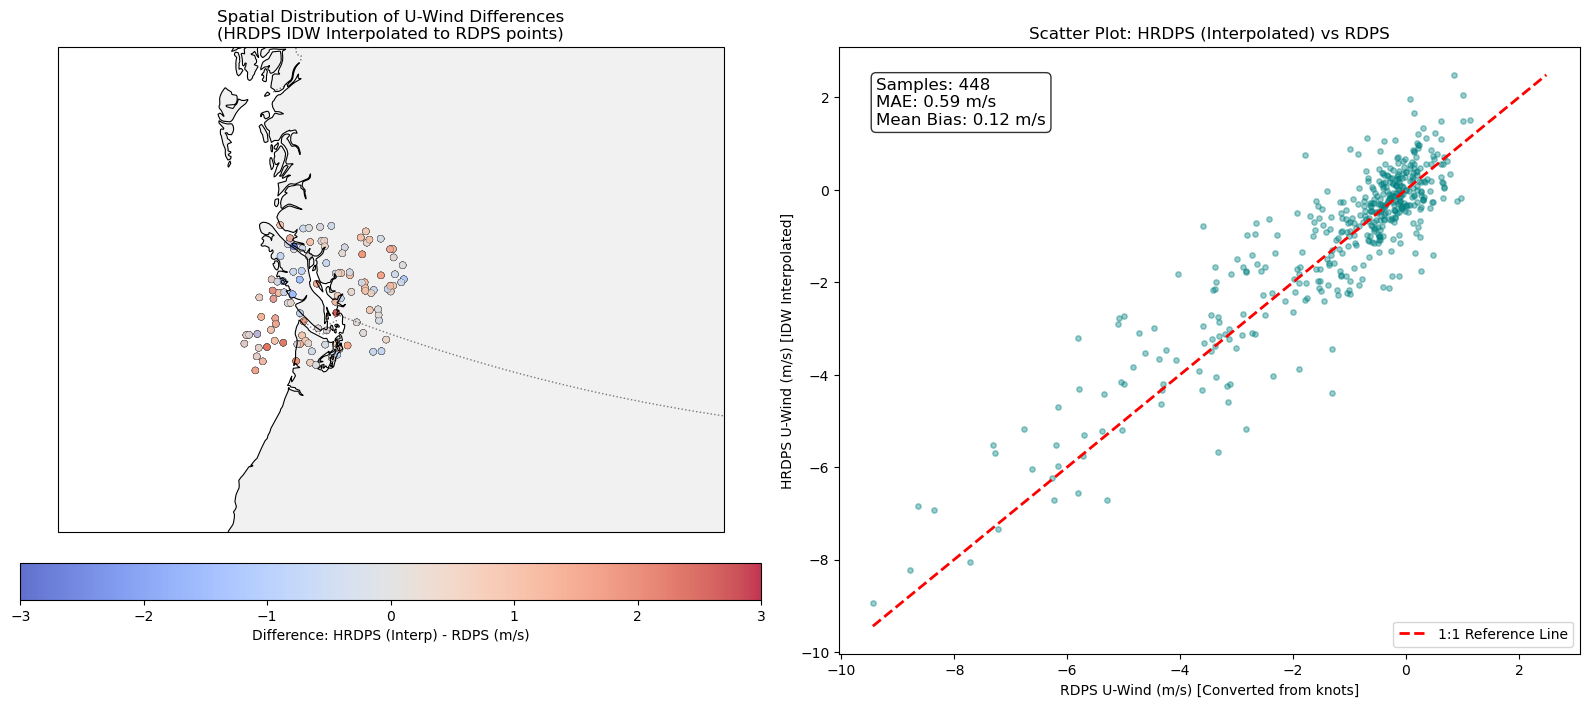

In [9]:
# Plot Comparison

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.spatial import cKDTree
import random

def idw_interpolation(tree, target_lat, target_lon, hrdps_values_flat, k=4, power=2):
    """
    反距离加权插值 (Inverse Distance Weighting)
    """
    # 查找最近的 k 个点
    distances, indices = tree.query([target_lat, target_lon], k=k)
    
    # 如果其中有一个点的距离极其接近 0，直接返回该点的值（避免除以 0）
    if distances[0] < 1e-10:
        return hrdps_values_flat[indices[0]]
    
    # 计算权重（距离的倒数的 power 次方）
    weights = 1.0 / (distances ** power)
    
    # 计算加权平均值
    interpolated_value = np.sum(weights * hrdps_values_flat[indices]) / np.sum(weights)
    return interpolated_value


def plot_wind_difference():
    # 1. 设置随机种子，保证可重复性
    random.seed(42)
    np.random.seed(42)

    # 2. 文件路径
    rdps_file = '/home/jqiu/Programing/Projects/analysis-junqi/Atmospheric_Forcing/Data_CaSR/Data_2024/Merged_2024/CaSR_v3.2_P_UUC_10m_merged_2024.nc'
    hrdps_file = '/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2024m01d01.nc'

    print("正在加载数据集...")
    ds_rdps = xr.open_dataset(rdps_file)
    ds_hrdps = xr.open_dataset(hrdps_file)

    # 3. 提取经纬度并构建 HRDPS 的 KDTree (反转：建在高清数据上)
    print("正在处理经纬度并构建高分辨率 (HRDPS) 空间索引...")
    lat_hrdps = ds_hrdps['nav_lat'].values
    lon_hrdps = ds_hrdps['nav_lon'].values
    lon_hrdps = np.where(lon_hrdps > 180, lon_hrdps - 360, lon_hrdps)
    
    # 过滤 HRDPS 无效坐标点
    valid_hrdps_mask = ~np.isnan(lat_hrdps) & ~((np.isclose(lat_hrdps, 0)) & (np.isclose(lon_hrdps, 0)))
    hrdps_coords = np.column_stack((lat_hrdps[valid_hrdps_mask], lon_hrdps[valid_hrdps_mask]))
    
    # 构建 HRDPS 的树
    tree_hrdps = cKDTree(hrdps_coords)

    # 处理 RDPS 经纬度
    lat_rdps_name = next((v for v in ['lat', 'latitude', 'nav_lat'] if v in ds_rdps.variables), None)
    lon_rdps_name = next((v for v in ['lon', 'longitude', 'nav_lon'] if v in ds_rdps.variables), None)
    lat_rdps = ds_rdps[lat_rdps_name].values
    lon_rdps = ds_rdps[lon_rdps_name].values
    lon_rdps = np.where(lon_rdps > 180, lon_rdps - 360, lon_rdps)

    if lat_rdps.ndim == 1:
        lon_rdps_2d, lat_rdps_2d = np.meshgrid(lon_rdps, lat_rdps)
    else:
        lon_rdps_2d, lat_rdps_2d = lon_rdps, lat_rdps

    # 4. 在 RDPS 中随机抽取有效点作为采样基准
    valid_rdps_mask = ~np.isnan(lat_rdps_2d) & ~np.isnan(lon_rdps_2d)
    valid_rdps_indices = np.where(valid_rdps_mask)
    num_samples = 200
    sample_idx = random.sample(range(len(valid_rdps_indices[0])), num_samples)

    # 选取 2024年1月1日的 4 个时刻
    target_times = ['2024-01-01T00:00:00', '2024-01-01T06:00:00', 
                    '2024-01-01T12:00:00', '2024-01-01T18:00:00']

    all_rdps_u_ms = []
    all_hrdps_u_interp = []
    all_lats = []
    all_lons = []
    all_diffs = []

    print(f"正在对比 {len(target_times)} 个时刻的数据 (使用 IDW 插值)...")

    for t_str in target_times:
        try:
            # 提取数据
            h_step = ds_hrdps.sel(time_counter=t_str, method='nearest')['u_wind'].values
            r_step = ds_rdps.sel(time=t_str, method='nearest')['CaSR_v3.2_P_UUC_10m'].values
            
            # 拉平 HRDPS 数据以对应 KDTree 的索引
            h_step_flat = h_step[valid_hrdps_mask]

            for idx in sample_idx:
                y_idx, x_idx = valid_rdps_indices[0][idx], valid_rdps_indices[1][idx]
                t_lat, t_lon = lat_rdps_2d[y_idx, x_idx], lon_rdps_2d[y_idx, x_idx]
                
                # 获取 RDPS 基准风速 (转换为 m/s)
                r_u_kts = r_step[y_idx, x_idx]
                if np.isnan(r_u_kts): continue
                r_u_ms = r_u_kts * 0.514444

                # 检查距离 (确保 RDPS 点在 HRDPS 覆盖范围内)
                dist_nearest, _ = tree_hrdps.query([t_lat, t_lon], k=1)
                if dist_nearest > 0.2: 
                    continue # 如果最近的点都很远，说明越界了

                # 在 HRDPS 场中执行 IDW 插值
                h_u_interp = idw_interpolation(tree_hrdps, t_lat, t_lon, h_step_flat, k=4)
                
                if np.isnan(h_u_interp): continue

                all_rdps_u_ms.append(r_u_ms)
                all_hrdps_u_interp.append(h_u_interp)
                all_lats.append(t_lat)
                all_lons.append(t_lon)
                # 计算差异 (高分辨率 - 低分辨率基准)
                all_diffs.append(h_u_interp - r_u_ms)
                
        except Exception as e:
            print(f"处理时刻 {t_str} 时出错: {e}")
            continue

    ds_rdps.close()
    ds_hrdps.close()

    if not all_rdps_u_ms:
        print("没有收集到有效数据点，请检查时间或坐标匹配。")
        return

    # 5. 开始画图
    print(f"成功收集到 {len(all_rdps_u_ms)} 个对比对，正在生成图表...")
    fig = plt.figure(figsize=(16, 7))

    # --- 子图 1: 空间误差分布地图 ---
    ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.LambertConformal(central_longitude=-90, central_latitude=50))
    ax1.set_extent([-135, -105, 45, 55], crs=ccrs.PlateCarree()) # 温哥华周边
    
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax1.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
    ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

    # 散点图
    sc = ax1.scatter(all_lons, all_lats, c=all_diffs, cmap='coolwarm', 
                     vmin=-3, vmax=3, s=25, alpha=0.8, edgecolors='k', linewidth=0.2, transform=ccrs.PlateCarree())
    plt.colorbar(sc, ax=ax1, orientation='horizontal', pad=0.05, label='Difference: HRDPS (Interp) - RDPS (m/s)')
    ax1.set_title('Spatial Distribution of U-Wind Differences\n(HRDPS IDW Interpolated to RDPS points)')

    # --- 子图 2: 散点相关性图 ---
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.scatter(all_rdps_u_ms, all_hrdps_u_interp, alpha=0.4, s=15, color='teal')
    
    # 画 1:1 对角线
    min_val = min(min(all_rdps_u_ms), min(all_hrdps_u_interp))
    max_val = max(max(all_rdps_u_ms), max(all_hrdps_u_interp))
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='1:1 Reference Line')
    
    # 统计信息
    mae = np.mean(np.abs(np.array(all_diffs)))
    bias = np.mean(np.array(all_diffs))
    
    ax2.set_xlabel('RDPS U-Wind (m/s) [Converted from knots]')
    ax2.set_ylabel('HRDPS U-Wind (m/s) [IDW Interpolated]')
    ax2.set_title('Scatter Plot: HRDPS (Interpolated) vs RDPS')
    ax2.legend()
    
    stats_text = f"Samples: {len(all_rdps_u_ms)}\nMAE: {mae:.2f} m/s\nMean Bias: {bias:.2f} m/s"
    ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    plot_wind_difference()